In [1]:
!pip install textblob

In [2]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/kritanjalijain/amazon-reviews/train.csv')

df.head()

,2,Stuning even for the non-gamer,This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^
0,2,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...
1,2,Amazing!,This soundtrack is my favorite music of all ti...
2,2,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...
3,2,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine..."
4,2,an absolute masterpiece,I am quite sure any of you actually taking the...


In [4]:
!pip install textblob

In [8]:
import pandas as pd

df = pd.read_csv(
    '/kaggle/input/datasets/kritanjalijain/amazon-reviews/train.csv',
    header=None,
    names=['label', 'title', 'text']
)

df.head()

,label,title,text
0,2,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...
1,2,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...
2,2,Amazing!,This soundtrack is my favorite music of all ti...
3,2,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...
4,2,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine..."


In [9]:
print(df.columns)

Index(['label', 'title', 'text'], dtype='object')


In [10]:
from textblob import TextBlob

sample_df = df.head(5000).copy()

def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

sample_df["Predicted_Sentiment"] = sample_df["text"].apply(get_sentiment)

sample_df.head()

,label,title,text,Predicted_Sentiment
0,2,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...,Negative
1,2,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...,Positive
2,2,Amazing!,This soundtrack is my favorite music of all ti...,Positive
3,2,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...,Positive
4,2,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine...",Positive


In [11]:
counts = sample_df["Predicted_Sentiment"].value_counts()

print(counts)

Predicted_Sentiment
Positive    3687
Negative    1182
Neutral      131
Name: count, dtype: int64


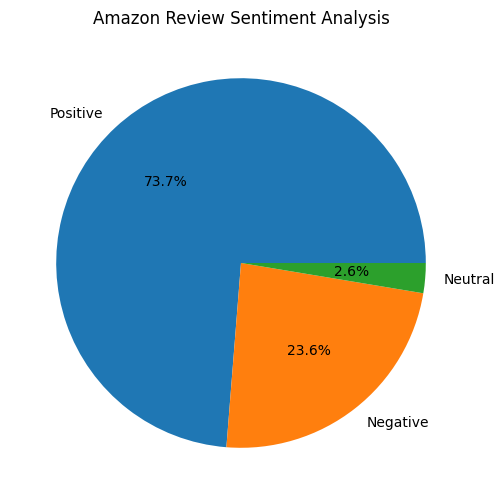

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("Amazon Review Sentiment Analysis")
plt.show()